# Figures 9, 10

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from my_help_functions.visualise_arch import ArchVisualiser
from damo.config.base import parse_config
import torch

config = parse_config('./configs/damoyolo_tinynasL20_T.py')
archvis = ArchVisualiser('my_help_functions/model_arch.json')

plt.rcParams['font.size'] = 24

In [ ]:
# to create pkl files with angles
# run 
# python tools/calculate_angles_yolo.py --data_names_file="fig_9_10.txt"

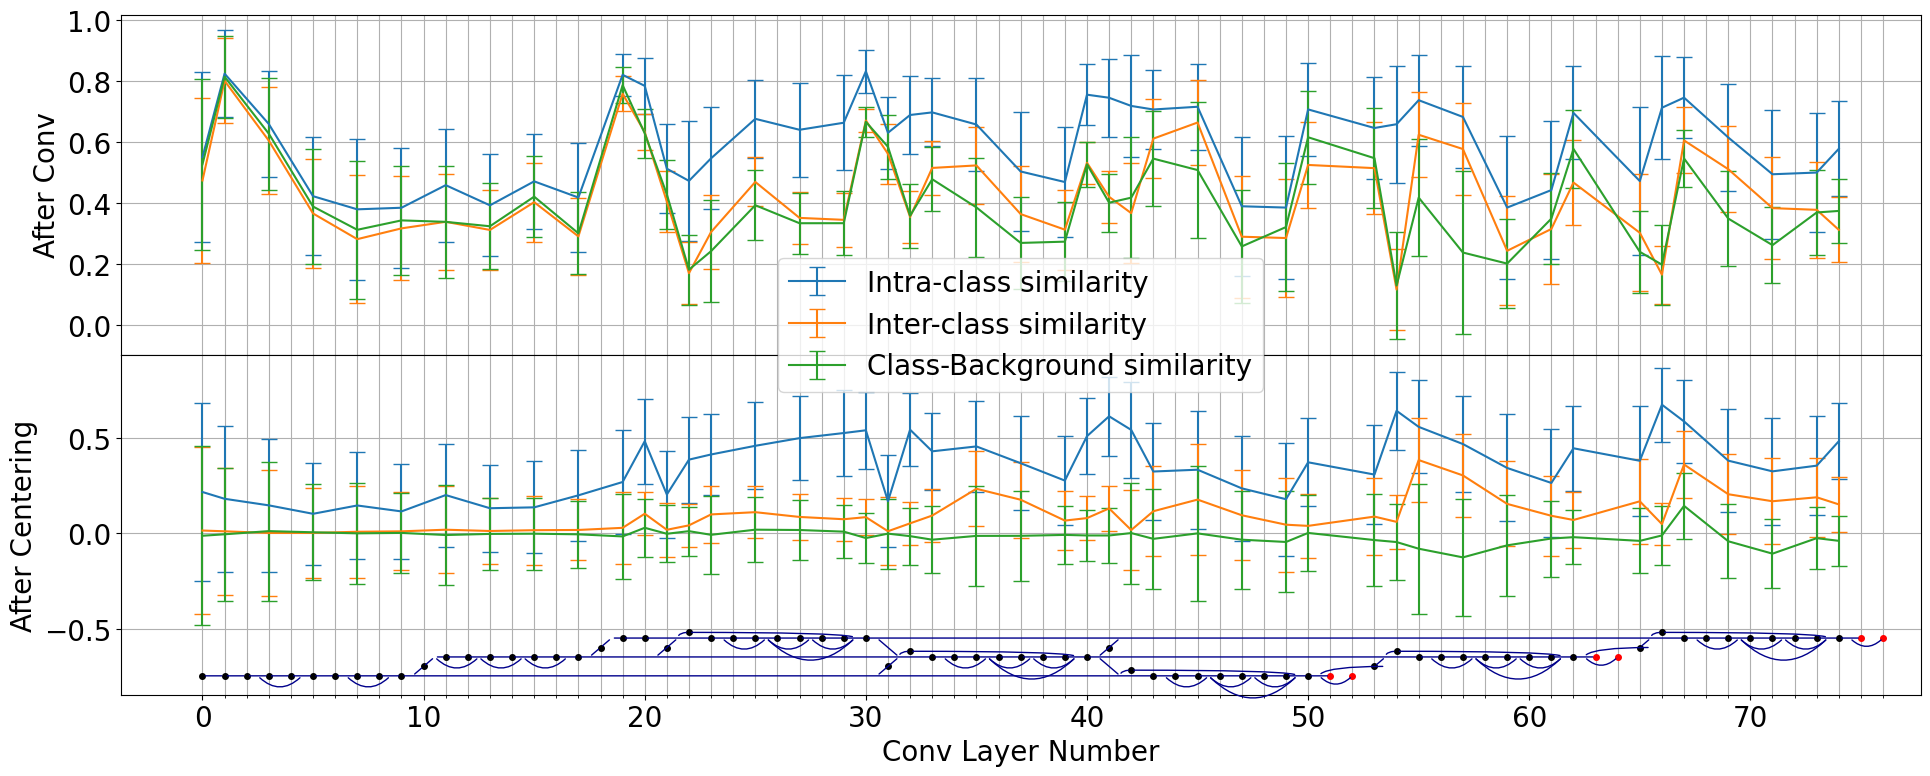

In [12]:
# Figure 9:
SAVE_FILE_NAME, PLOT_INFO = 'heap/test_after.pdf', [('After_conv', 'After Conv'), ('After_center', 'After Centering')]

# Figure 10:
# SAVE_FILE_NAME, PLOT_INFO = 'heap/test_while.pdf', [('Before_conv_vs_After_conv', 'While Conv'), ('Before_center_vs_After_center', 'While Centering')]

pdf = PdfPages(SAVE_FILE_NAME)

fig = plt.figure(figsize=(20, 8))

ax1 = fig.add_axes([0.07, 0.525, 0.9, 0.425])
ax2 = fig.add_axes([0.07, 0.1,   0.9, 0.425])

PATH = 'heap/angles/'
for ax, (LAYER_DATA_NAME, LAYER_DATA_LABEL) in zip((ax1, ax2), PLOT_INFO):
    ax.set_ylabel(LAYER_DATA_LABEL)
    
    with open(PATH + LAYER_DATA_NAME + '.pkl', 'rb') as fr:
        res = pickle.load(fr)

    mss = np.zeros((81, 81), dtype=bool); np.fill_diagonal(mss[:80, :80], 1)
    mso = np.triu(np.ones((81, 81), dtype=bool), k=1); mso[:, 80] = 0
    msb = np.zeros((81, 81), dtype=bool); msb[:80, 80] = 1
    mbb = np.zeros((81, 81), dtype=bool); mbb[80, 80] = 1
    QUANTILE_USED = False

    for label, mask in [
        ('Intra-class similarity', mss),
        ('Inter-class similarity', mso),
        ('Class-Background similarity', msb),
    ]:
        xs, m, s = [], [], []
        for i, layer_name in enumerate(archvis.forward_order):
            if not layer_name in res: 
                pass
            else:
                if 'var' in res[layer_name]:
                    s.append(np.sqrt(np.nanmean(res[layer_name]['var'][mask])))
                    m.append(np.nanmean(res[layer_name]['mean'][mask]))
                else:
                    QUANTILE_USED = True
                    m.append(np.nanmean(res[layer_name]['q0.50'][mask]))
                    s.append([
                        m[-1] - np.nanmean(res[layer_name]['q0.25'][mask]),
                        np.nanmean(res[layer_name]['q0.75'][mask]) - m[-1]
                    ])
                xs.append(i)
        m, s = np.array(m), np.array(s)
        ax.errorbar(xs, m, s.T, label=label, capsize=6)

archvis(ax2)
ax1.set_xticks(ax2.get_xticks(minor=True), minor=True)
ax1.set_xticklabels([])
ax1.grid(which='both')
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, 0.85))

pdf.savefig()
pdf.close()

plt.show()

# Figures 1, 7 preparation

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import os
import torch
import torch.nn.functional as F
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
%matplotlib inline

from damo.config.base import parse_config
from damo.dataset import build_dataloader
from tools.demo import Infer

from my_help_functions.hooks import register_hooks
from my_help_functions.datasets import CustomCocoDataset
from my_help_functions.visualise_arch import ArchVisualiser
from my_help_functions.figure17 import BatchT, get_sampled_cos, plot_S_arrow

from damo.utils import fuse_bn_running_var

In [2]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="4"

In [3]:
from torch import distributed

try:
    rank = int(os.environ["RANK"])
    local_rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])
    distributed.init_process_group("nccl")
except KeyError:
    rank = 0
    local_rank = 0
    world_size = 1
    distributed.init_process_group(
        backend="nccl",
        init_method="tcp://127.0.0.1:12585",
        rank=rank,
        world_size=world_size,
    )

In [4]:
config = parse_config('./configs/damoyolo_tinynasL20_T.py')
device = 'cuda'
infer_engine = Infer(config, device=device,
    ckpt='./damoyolo_tinynasL20_T_420.pth')
model = fuse_bn_running_var(infer_engine.model.eval())

archvis = ArchVisualiser('my_help_functions/model_arch.json')

Inference with torch engine!


In [7]:
coco_ds = CustomCocoDataset(config, load_train=False)
coco_dl = build_dataloader([coco_ds],
                           config.test.augment,
                           32, # no need to change cause used certain images
                           num_workers=config.miscs.num_workers,
                           is_train=False)[0]

loading annotations into memory...
Done (t=0.98s)
creating index...
index created!


# Figure 1

In [8]:
LAYER_DATA_NAME, LAYER_F = 'Conv Output', lambda l: 'output'

b = next(iter(coco_dl))
batch = BatchT(b, device, config)

base_mask, _ = batch.create_mask((80, 80))
model.head.train()
with torch.no_grad():
    output = model(batch.imgs, [t.to(device) for t in b[1]])
model.head.eval()
batch.init_mask_by_pos_inds(output['pos_inds'], output['pos_labels'])
model_mask, _ = batch.create_mask((80, 80))

model.head.train()
with torch.no_grad():
    output = model(batch.imgs, [t.to(device) for t in b[1]])
model.head.eval()
batch.init_mask_by_pos_inds(output['pos_inds'], output['pos_labels'])

hooks, layer_input_fwd = register_hooks(model, archvis.forward_order, LAYER_F(None))
with torch.no_grad():
    output = model(batch.imgs)
for h in hooks.values(): 
    h.remove()
hooks.clear()
torch.cuda.empty_cache()

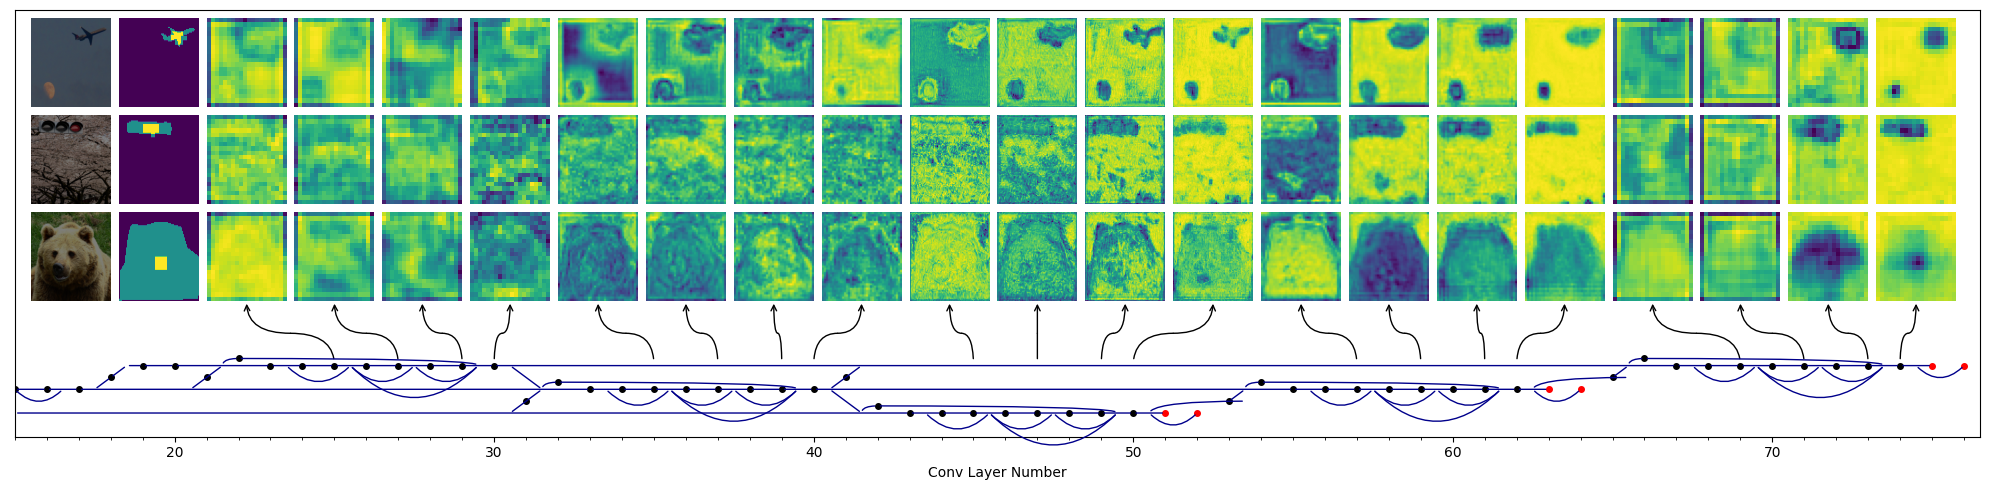

In [9]:
pdf = PdfPages("heap/test_fig1_new.pdf")

fig, ax = plt.subplots(figsize=(20, 5))
target_layers_ids = [a + b for b in [22, 32, 42, 54, 66] for a in [3, 5, 7, 8]]

image_y = 1
for img_id in [0, 9, 20]:
    image_x = 15.5
    image_dy = 1.5
    image_dx = (76 - image_x) / (len(target_layers_ids) + 2)
    image_h = image_dy/1.1
    image_w = image_dx/1.1

    im = ax.imshow(batch.imgs.tensors[img_id].permute(1, 2, 0).cpu() / 512, extent=[image_x, image_x+image_w, image_y, image_y+image_h], aspect='auto', zorder=5)
    image_x += image_dx
    im = ax.imshow((base_mask[:, img_id].any(0).long() + model_mask[:, img_id].any(0).long()).cpu(), extent=[image_x, image_x+image_w, image_y, image_y+image_h], aspect='auto', zorder=5)
    image_x += image_dx

    for j, n in enumerate(archvis.forward_order):
        if not j in target_layers_ids:
            continue
        mid = [i for i, (mn, _) in enumerate(model.named_modules()) if mn == n][0]
        next_bn = list(model.named_modules())[mid+1][1]
        if not isinstance(next_bn, torch.nn.BatchNorm2d): continue

        a = torch.einsum('jkl,j->kl', F.normalize(layer_input_fwd[n][img_id], dim=0), F.normalize(next_bn.running_mean, dim=0))

        im = ax.imshow(a.cpu(), extent=[image_x, image_x+image_w, image_y, image_y+image_h], aspect='auto', zorder=5)

        if image_y == 1:
            plot_S_arrow(ax, image_x+1.25, image_y, j, 0, 90)
        image_x += image_dx
    image_y += image_dy

ax.set_ylim(0, image_y)
ax.set_xlim(15, 76.5)
archvis(ax)
ax.grid(visible=False, which='both')
ax.set_yticks([])

plt.tight_layout()
pdf.savefig()
pdf.close()

# Figure 7

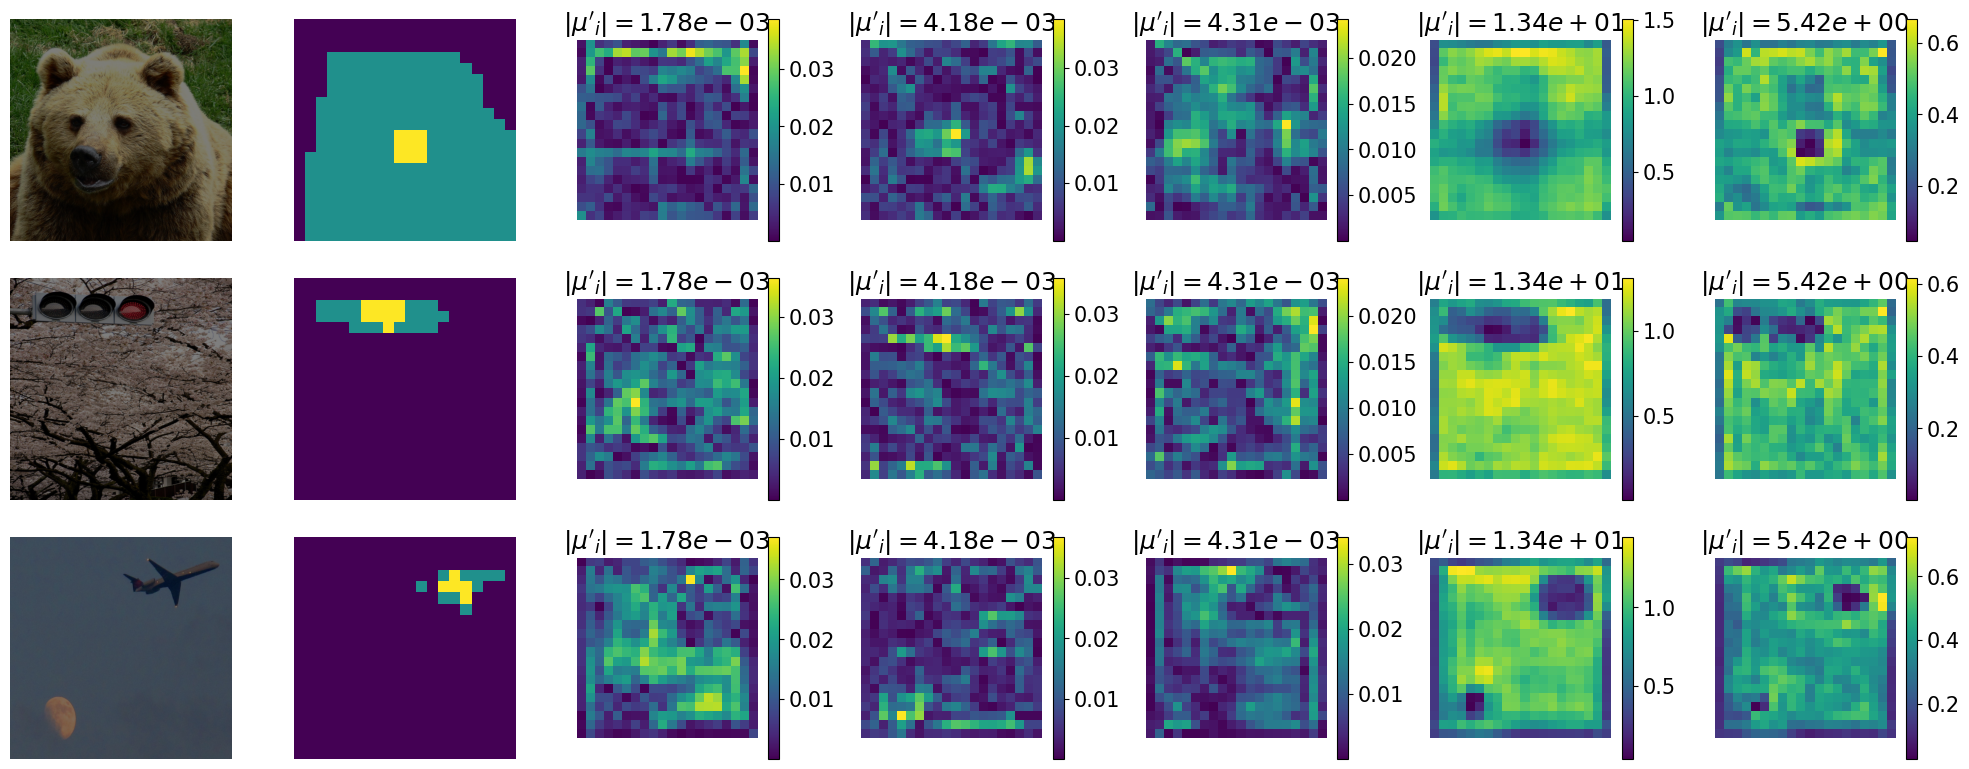

In [6]:
plt.rcParams['font.size'] = 15
pdf = PdfPages("heap/test_fig7.pdf")

fig, axs = plt.subplots(3, 7, figsize=(20, 8))

for img_id, layer_id, axs_row in zip([0, 9, 20], [74]*3, axs):
    
    LAYER_DATA_NAME, LAYER_F = 'Conv Input', lambda l: 'input'
    LAYER_NAME = archvis.forward_order[layer_id]
    mid = [i for i, (mn, _) in enumerate(model.named_modules()) if mn == LAYER_NAME][0]
    conv = list(model.named_modules())[mid][1]
    next_bn = list(model.named_modules())[mid+1][1]

    b = next(iter(coco_dl))
    batch = BatchT(b, device, config)

    base_mask, _ = batch.create_mask((20, 20))
    model.head.train()
    with torch.no_grad():
        output = model(batch.imgs, [t.to(device) for t in b[1]])
    model.head.eval()
    batch.init_mask_by_pos_inds(output['pos_inds'], output['pos_labels'])
    model_mask, _ = batch.create_mask((20, 20))

    hooks, layer_input_fwd = register_hooks(model, [LAYER_NAME], LAYER_F(None))
    with torch.no_grad():
        output = model(batch.imgs)
    for h in hooks.values(): 
        h.remove()
    hooks.clear()
    torch.cuda.empty_cache()

    in_ = layer_input_fwd[LAYER_NAME][img_id]

    w_pre = conv.weight.detach().permute(0, 2, 3, 1)
    
    try:
        # PyTorch 1.9+
        svd_weight = torch.linalg.svd(w_pre.flatten(1), full_matrices=False)
        U, S, Vh = svd_weight.U, svd_weight.S, svd_weight.Vh
    except AttributeError:
        U, S, V = torch.svd(w_pre.flatten(1))
        Vh = V.T
#     svd_weight = torch.linalg.svd(w_pre.flatten(1), full_matrices=False)
    Vh_weight = Vh.reshape(w_pre.shape).permute(0, 3, 1, 2)

    norms = []
    center_after_s = (U.T @ next_bn.running_mean)

    for i in range(center_after_s.size(0)):
        Vh_weight_cuted = torch.zeros_like(Vh_weight)
        Vh_weight_cuted[i] = Vh_weight[i].detach() * S[i]

        x = F.conv2d(F.normalize(in_, dim=0)[None], Vh_weight_cuted, bias=None, stride=conv.stride, padding=conv.padding, dilation=conv.dilation)

        norms.append(x[0].norm(dim=0))

    norms = torch.stack(norms)

    axs_row[0].imshow(batch.imgs.tensors[img_id].permute(1, 2, 0).cpu() / 512)
    axs_row[0].set_axis_off()
    axs_row[1].imshow((base_mask[:, img_id].any(0).long() + model_mask[:, img_id].any(0).long()).cpu())
    axs_row[1].set_axis_off()
    
    ax_id = 2
    for i, t in enumerate(torch.argsort(center_after_s.abs(), descending=False)[:3]):
        im = axs_row[ax_id].imshow(norms[t].cpu())
        fig.colorbar(im, ax=axs_row[ax_id])

        axs_row[ax_id].set_title(f"$|\mu'_i|={center_after_s[t].abs().item():.2e}$")
        axs_row[ax_id].set_axis_off()
        ax_id += 1
    
    for i, t in enumerate(torch.argsort(center_after_s.abs(), descending=True)[:2]):
        im = axs_row[ax_id].imshow(norms[t].cpu())
        fig.colorbar(im, ax=axs_row[ax_id])

        axs_row[ax_id].set_title(f"$|\mu'_i|={center_after_s[t].abs().item():.2e}$")
        axs_row[ax_id].set_axis_off()
        ax_id += 1
    
plt.tight_layout()
pdf.savefig()
pdf.close()

# Figure 6 Preparation

In [ ]:
# to create pkl files with angles
# run 
# python tools/calculate_angles_yolo.py --data_names_file="fig_6.txt"

In [4]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pickle
import numpy as np

from my_help_functions.visualise_arch import ArchVisualiser
archvis = ArchVisualiser('my_help_functions/model_arch.json')

In [ ]:
PATH = 'heap/angles/'

mss = np.zeros((81, 81), dtype=bool)
np.fill_diagonal(mss[:80, :80], 1)

mso = np.triu(np.ones((81, 81), dtype=bool), k=1)
mso[:, 80] = 0

msb = np.zeros((81, 81), dtype=bool)
msb[:80, 80] = 1

layer_names = [
    'After_conv',
    'After_center',
    'After_bias',
    'After_shifting',
    'Before_conv_vs_After_conv',
    'Before_center_vs_After_center',
    'Before_bias_vs_After_bias',
    'Before_shifting_vs_After_shifting',
]


def format_metrics(avg_metrics):
    labels = ['in', 'out', 'back']
    parts = []

    for i, label in enumerate(labels):
        mean = avg_metrics[2 * i]
        std = avg_metrics[2 * i + 1]
        parts.append(f'{label} {mean:.2f}±{std:.2f}<br>')

    return ''.join(parts)


cells = []

for layer_data_name in layer_names:
    with open(PATH + layer_data_name + '.pkl', 'rb') as fr:
        res = pickle.load(fr)

    layer_stats = {}

    for layer_name in archvis.forward_order:
        if layer_name not in res:
            continue
        if 'var' not in res[layer_name]:
            continue

        layer_data = res[layer_name]
        metrics = []

        for mask in (mss, mso, msb):
            m_val = np.nanmean(layer_data['mean'][mask])
            s_val = np.sqrt(np.nanmean(layer_data['var'][mask]))
            metrics.extend([m_val, s_val])

        layer_stats[layer_name] = metrics

    all_metrics = np.array(list(layer_stats.values()))
    avg_metrics = np.mean(all_metrics, axis=0)

    cells.append(format_metrics(avg_metrics))

s = f"""
| YOLO | After Conv | After Centering | After Bias | After Shifting | $\\Delta$ After Conv | $\\Delta$ After Centering | $\\Delta$ After Bias | $\\Delta$ After Shifting |
| -- | -- | -- | -- | -- | -- | -- | -- | -- |
| Mean & Bias | {' | '.join(cells)} |
"""

print(s)

## Figure 8 Preparation

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pickle
import numpy as np

from collections import defaultdict

from my_help_functions.visualise_arch import ArchVisualiser
archvis = ArchVisualiser('my_help_functions/model_arch.json')

In [ ]:
# to create pkl files with angles
# run
# python tools/calculate_angles_yolo.py --data_names_file="fig_8.txt"

In [ ]:
PATH = f'heap/angles/'
VS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

RES = defaultdict(list)
for v in VS:
    for t in ['top', 'low']:
        for s in ['center', 's']:
            CORR_TYPE = f'{t}_by_{s}_{v}_norm'
            LAYER_DATA_NAME = f'Fig8_While_Conv_{CORR_TYPE}'
            
            with open(PATH + LAYER_DATA_NAME + '.pkl', 'rb') as fr:
                    res = pickle.load(fr)

            xs, m, s = [], [], []
            for x, layer_name in enumerate(archvis.forward_order):
                if not layer_name in res: 
                    pass
                else:
                    if 'var' in res[layer_name]:
                        s.append(np.sqrt(np.nanmean(res[layer_name]['var'])))
                        m.append(np.nanmean(res[layer_name]['mean']))
                    else:
                        raise
                    xs.append(x)
            m, s = np.array(m), np.array(s)
            RES[LAYER_DATA_NAME.replace(str(v), '_')].append((np.nanmean(m), np.nanmean(s)))
            
r = {}
for k, v in RES.items():
    k_ = k.replace('Fig8_While_Conv_', '').replace('___norm', '').replace('_', ' ')
    k_ = k_[0].upper() + k_[1:]
    
    r[k_] = ([round(v_[0], 5) for v_ in v], [round(v_[1], 5) for v_ in v])

print(r)